# Banded ridge for feature-specific regularization

This example combines an impulse-like feature with a smooth continuous feature. The smooth feature creates a poorly conditioned lagged design matrix, while the impulse feature remains relatively well identified. A single global ridge penalty shrinks both TRFs; `feature_alphas` lets us regularize only the smooth feature.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from pyeeg.models import TRFEstimator
from pyeeg.utils import lag_matrix


INFO:pyeeg:Successfully loaded makeRateMap_c Python extension module.
INFO:pyeeg:Successfully loaded gammatone_c Python extension module.
/home/hugo/Projects/Work/pyEEG/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/hugo/Projects/Work/pyEEG/pyeeg/features/__init__.py:20: UserWarning: Missing torch module, will not be able to create LLMFeatureExtractor. Instal torch to use this module (all optional deps installable via natmeeg[features])
  warn("Missing torch module, will not be able to create LLMFeatureExtractor. Instal torch to use this module (all optional deps installable via natmeeg[features])")
/home/hugo/Projects/Work/pyEEG/pyeeg/features/__init__.py:22: UserWarning: Using a dummy value for LLMFeatureExtractor as torch is unavailable
  warn("Using a dummy value for LLMFeatureExtractor

In [36]:
rng = np.random.default_rng(18)
n_samples = int(1e3)
n_lags = 41
t = np.arange(n_samples)
impulses = (rng.random(n_samples) < 0.035).astype(float)
smooth = gaussian_filter1d(rng.standard_normal(n_samples), sigma=100)
smooth = (smooth - smooth.mean()) / smooth.std()
X = np.column_stack([impulses, smooth])
lags = np.arange(n_lags)
true_coef = np.column_stack([
    np.exp(-((lags - 8) / 3) ** 2),
    0.8 * np.exp(-((lags - 24) / 10) ** 2),
])
design = lag_matrix(X, lags=lags, mode='full', fill_value=0., block_order='features')
y = design @ true_coef[::-1].reshape(-1, 1, order='F') + 0.35 * rng.standard_normal((n_samples, 1))
print('condition number:', np.linalg.cond(design))


condition number: 137.7283622161797


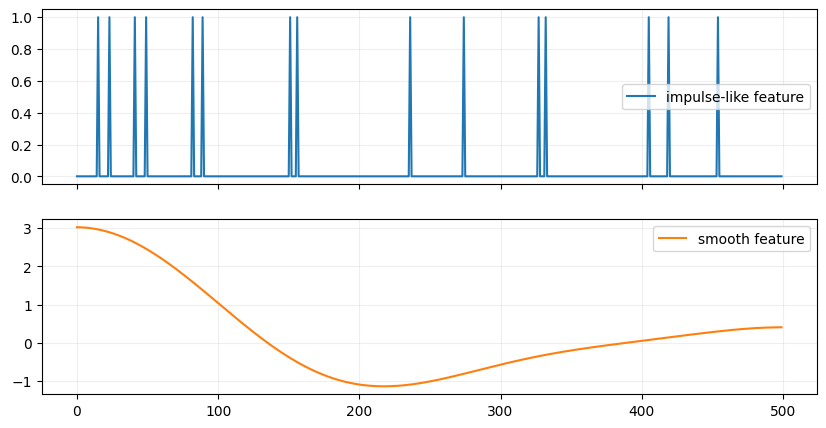

In [37]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 5))
ax[0].plot(X[:500, 0], label='impulse-like feature')
ax[1].plot(X[:500, 1], label='smooth feature', color='tab:orange')
for a in ax: a.legend(); a.grid(alpha=.2)


In [64]:
no_ridge = TRFEstimator(times=lags[::-1], alpha=0., fit_intercept=False,
                            block_order='features', verbose=False)
global_ridge = TRFEstimator(times=lags[::-1], alpha=50., fit_intercept=False,
                            block_order='features', verbose=False)
banded_ridge = TRFEstimator(times=lags[::-1], feature_alphas=[0., 50.],
                            fit_intercept=False, block_order='features',
                            verbose=False)
no_ridge.fit(X, y, drop=False)
global_ridge.fit(X, y, drop=False)
banded_ridge.fit(X, y, drop=False)


,times,"array([40, 39..., 2, 1, 0])"
,tmin,None
,tmax,None
,srate,1.0
,alpha,0.0
,fit_intercept,False
,verbose,False
,quadratic_reg,None
,block_order,'features'
,loss,'linear'
,robust_solver,'irls'


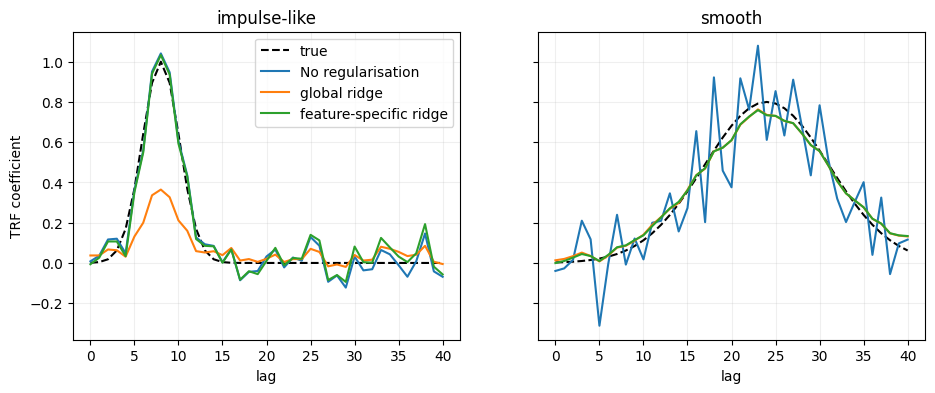

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(11, 4))
for feature, title, axis in zip(range(2), ['impulse-like', 'smooth'], ax):
    axis.plot(lags, true_coef[:, feature], 'k--', label='true')
    axis.plot(lags, no_ridge.coef_[:, feature, 0], label='No regularisation')
    axis.plot(lags, global_ridge.coef_[:, feature, 0], label='global ridge')
    axis.plot(lags, banded_ridge.coef_[:, feature, 0], label='feature-specific ridge')
    axis.set_title(title); axis.set_xlabel('lag'); axis.grid(alpha=.2)
ax[0].set_ylabel('TRF coefficient'); ax[0].legend()


The first feature receives zero ridge while the smooth feature receives a strong penalty. In practice, choose the values in `feature_alphas` by validation or prior knowledge; this notebook deliberately fixes them to make the effect visible.